# The Lorenz-96 Two-Timescale System





In 1996, Lorenz proposed a two-time scale dynamical system, referred to as the Lorenz-96 model (L96), whose behavior mimics the non-linear dynamics of the extratropical atmosphere with simplified representation of multiscale interactions and nonlinear advection {cite:p}`Lorenz1995`. The L96 model consists of two sets of equations coupling two sets of variables ($X_k$ and $Y_{j,k}$), which evolve over two (slow and fast) timescales and are arranged around a latitude circle as shown in Fig. 1. The equations comprising L96 are:
\begin{align}
\frac{d}{dt} X_k
&= - X_{k-1} \left( X_{k-2} - X_{k+1} \right) - X_k + F - \left( \frac{hc}{b} \right) \sum_{j=0}^{J-1} Y_{j,k},
\\
\frac{d}{dt} Y_{j,k}
&= - cbY_{j+1,k} \left( Y_{j+2,k} - Y_{j-1,k} \right) - c Y_{j,k} + \frac{hc}{b} X_k
\end{align}

where $X_k$, $k=1,\ldots,K$, denotes $K$ slow (or low-frequency) variables, and $Y_{j,k}$ , $j=1,\ldots,J$ denotes $J*K$ fast (or high-frequency) variables. 
The slow equations are coupled to the fast equations via a coupling term, $\sum_{j=0}^{J-1} Y_{j,k}$, which sums over the $J$ fast variables corresponding to a particular $k$. On the other hand, each fast equation is forced by a coupling term, $\frac{hc}{b} X_k$, that depends on the slow variable corresponding to that particular $k$. 

The evolution of this two-time scale system depend on three key parameters: $b$, $c$ and $h$. Here $b$ determines the magnitude of the nonlinear interactions among the fast variables, $c$ controls how rapidly the fast variables fluctuate compared to the slow variables and, $h$ governs the strength of the coupling between the slow and fast variables. Moreover, the slow time-scale equation is forced by the parameter $F$, whose value determines the chaotic behaviour of the system. E.g. {cite:p}`Wilks2005`.

The chaotic dynamical system L96 is very useful for testing different numerical methods in atmospheric modeling thanks to its transparency, low computational cost and simplicity compared to Global Climate Models (GCM). The interaction between variables of different scales makes the L96 model of particular interest when evaluating new parameterization methodologies. As such, it was used in assessing different techniques that were later incorporated into GCMs ({cite}`Crommelin2008`, {cite}`Dorrestijn2013`).

The L96 model has been extensively used as a test bed in various studies including data assimilation approaches ({cite}`Law2016`, {cite}`Hatfield2017`), stochastic parameterization schemes ({cite}`Kwasniok2012`, {cite}`Arnold2013`, {cite}`Chorin2015`)  and Machine Learning-based parameterization methodologies ({cite}`Schneider2017`, {cite}`Dueben2018` , {cite}`Gagne2020`).


```{figure} https://www.researchgate.net/publication/319201436/figure/fig1/AS:869115023589376@1584224577926/Visualisation-of-a-two-scale-Lorenz-96-system-with-J-8-and-K-6-Global-scale-values.png
:width: 400px
:name: l96-equation-figure

*Visualisation of a two-scale Lorenz '96 system with J = 8 and K = 6. Global-scale variables ($X_k$) are updated based on neighbouring variables and on the local-scale variables ($Y_{j,k}$) associated with the corresponding global-scale variable. Local-scale variabless are updated based on neighbouring variables and the associated global-scale variable. The neighbourhood topology of both local and global-scale variables is circular. Image from [Exploiting the chaotic behaviour of atmospheric models with reconfigurable architectures - Scientific Figure on ResearchGate.](https://www.researchgate.net/figure/Visualisation-of-a-two-scale-Lorenz-96-system-with-J-8-and-K-6-Global-scale-values_fig1_319201436)*.
```


## Code to numerically integrate the two time-scale L96 model

In [7]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import os
import sys
from pathlib import Path

# Ensure we import the local repo (not a site-packages install)
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == 'notebooks' else cwd
sys.path.insert(0, str(repo_root))

import paleobeasts as pb
import importlib
import paleobeasts.signal_models.lorenz96 as l96
importlib.reload(l96)
from paleobeasts.signal_models.lorenz96 import Lorenz96TwoScale


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


An example of how to use the fixed-step RK4 integration is shown below. We use the model-specific
`method='l96_rk4'` option to match the original implementation exactly.

**Note on exact reproduction:** The original `L96_model.py` defines the fast-variable tendencies using
global rolling on the *flattened* `Y` array (i.e., it wraps across block boundaries).
Set `exact_rhs=True` to match that behavior exactly. If `exact_rhs=False` (default), the model
uses a blockwise roll within each `k` group, which is the more common textbook formulation.

In [8]:
K = 36  # Number of globa-scale variables X
J = 10  # Number of local-scale Y variables per single global-scale X variable
nt = 1000  # Number of time steps
si = 0.005  # Sampling time interval
dt = 0.005  # Time step
F = 10.0  # Focring
h = 1.0  # Coupling coefficient
b = 10.0  # ratio of amplitudes
c = 10.0  # time-scale ratio
t_span = (0, nt * si)


In [9]:
def s(k, K):
    """A non-dimension coordinate from -1..+1 corresponding to k=0..K"""
    return 2 * (0.5 + k) / K - 1

In [10]:
k = np.arange(K)  # For coordinate in plots
j = np.arange(J * K)  # For coordinate in plots

# Initial conditions
X_init = s(k, K) * (s(k, K) - 1) * (s(k, K) + 1)
Y_init = 0 * s(j, J * K) * (s(j, J * K) - 1) * (s(j, J * K) + 1)

y0 = np.concatenate([X_init, Y_init])


In [11]:
# Integrate using the original fixed-step RK4 scheme via the model-specific method
model = Lorenz96TwoScale(K=K, J=J, F=F, h=h, b=b, c=c, exact_rhs=True)
model.integrate(t_span=t_span, y0=y0, method='l96_rk4', kwargs={'dt': dt, 'si': si})

state = model.state_variables
X = np.column_stack([state[f'x{i}'] for i in range(K)])
Y = np.column_stack([state[f'y{i}'] for i in range(K * J)])
t = model.time


After running the model, we plot the results.

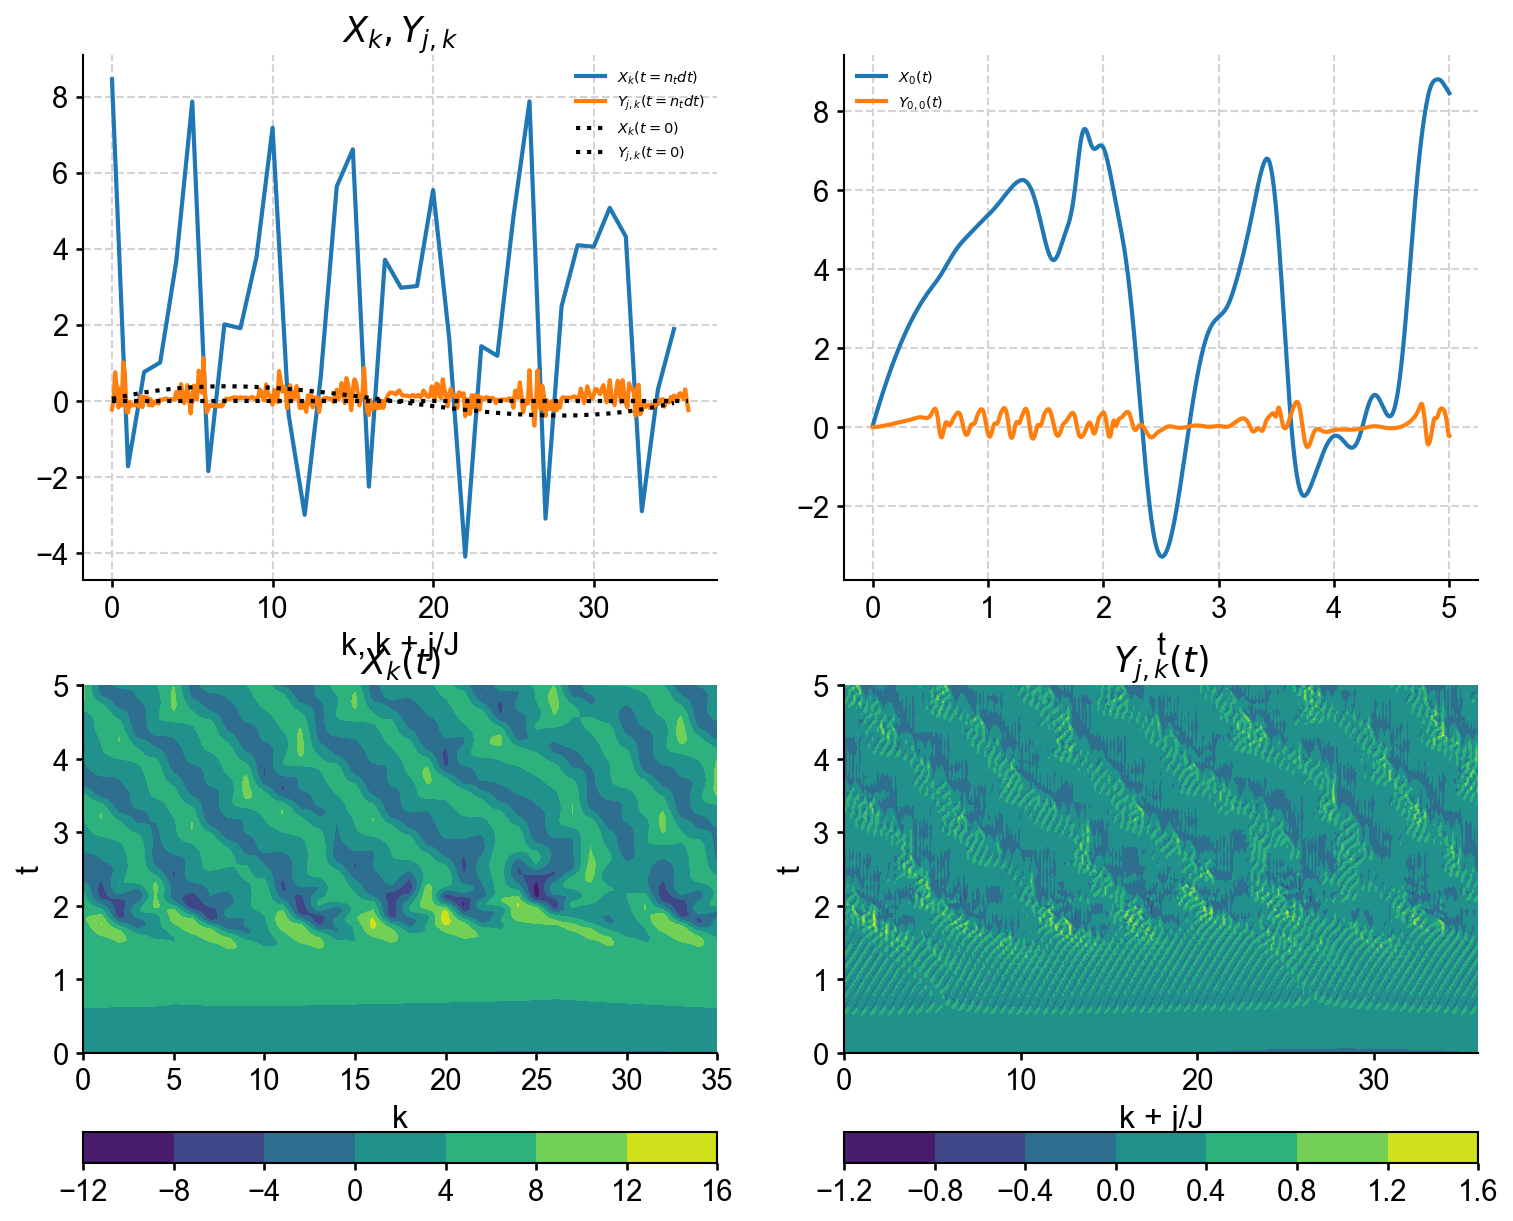

In [12]:
plt.figure(figsize=(12, 10), dpi=150)
plt.subplot(221)

# Snapshot of X[k]
plt.plot(k, X[-1], label="$X_k(t=n_t dt)$")
plt.plot(j / J, Y[-1], label="$Y_{j,k}(t=n_t dt)$")
plt.plot(k, X_init, "k:", label="$X_k(t=0)$")
plt.plot(j / J, Y_init, "k:", label="$Y_{j,k}(t=0)$")
plt.legend(fontsize=7)
plt.xlabel("k, k + j/J")
plt.title("$X_k, Y_{j,k}$")
plt.subplot(222)

# Sample time-series X[0](t), Y[0](t)
plt.plot(t, X[:, 0], label="$X_0(t)$")
plt.plot(t, Y[:, 0], label="$Y_{0,0}(t)$")
plt.legend(fontsize=7)
plt.xlabel("t")
plt.subplot(223)

# Full model history of X
plt.contourf(k, t, X)
plt.colorbar(orientation="horizontal")
plt.xlabel("k")
plt.ylabel("t")
plt.title("$X_k(t)$")
plt.subplot(224)

# Full model history of Y
plt.contourf(j / J, t, Y)
plt.colorbar(orientation="horizontal")
plt.xlabel("k + j/J")
plt.ylabel("t")
plt.title("$Y_{j,k}(t)$");

## Comparison: fixed-step RK4 vs adaptive RK45

Below we compare the fast variable `Y[0]` using the exact fixed-step RK4 method (`l96_rk4`)
and the default adaptive RK45 solver (with resampling to the same `si`).

In [13]:
# Adaptive RK45 + resample
model_adapt = Lorenz96TwoScale(K=K, J=J, F=F, h=h, b=b, c=c, exact_rhs=True)
model_adapt.integrate(t_span=t_span, y0=y0, method='RK45')
t_eval_adapt = pb.utils.define_t_eval(t_span, delta_t=si)
model_adapt.reframe_time_axis(t_eval_adapt, update_state=True)

state_adapt = model_adapt.state_variables
Y_adapt = np.column_stack([state_adapt[f'y{i}'] for i in range(K * J)])
t_adapt = model_adapt.time

plt.figure(figsize=(12, 4), dpi=150)
plt.plot(t_ref, Y_ref[:, 0], label='Y[0] (l96_rk4, exact rhs)', alpha=0.8)
plt.plot(t_adapt, Y_adapt[:, 0], label='Y[0] (adaptive RK45 + reframe)', alpha=0.7)
plt.xlabel('time')
plt.ylabel('Y[0]')
plt.title('Fixed-step RK4 vs adaptive RK45')
plt.legend()
plt.tight_layout()


NameError: name 't_ref' is not defined

<Figure size 1800x600 with 0 Axes>

## Example with time-varying forcing

You can pass a `pb.Forcing` object to drive the system with a time-varying *F(t)*.
Here we use a simple sinusoid around `F=10`.

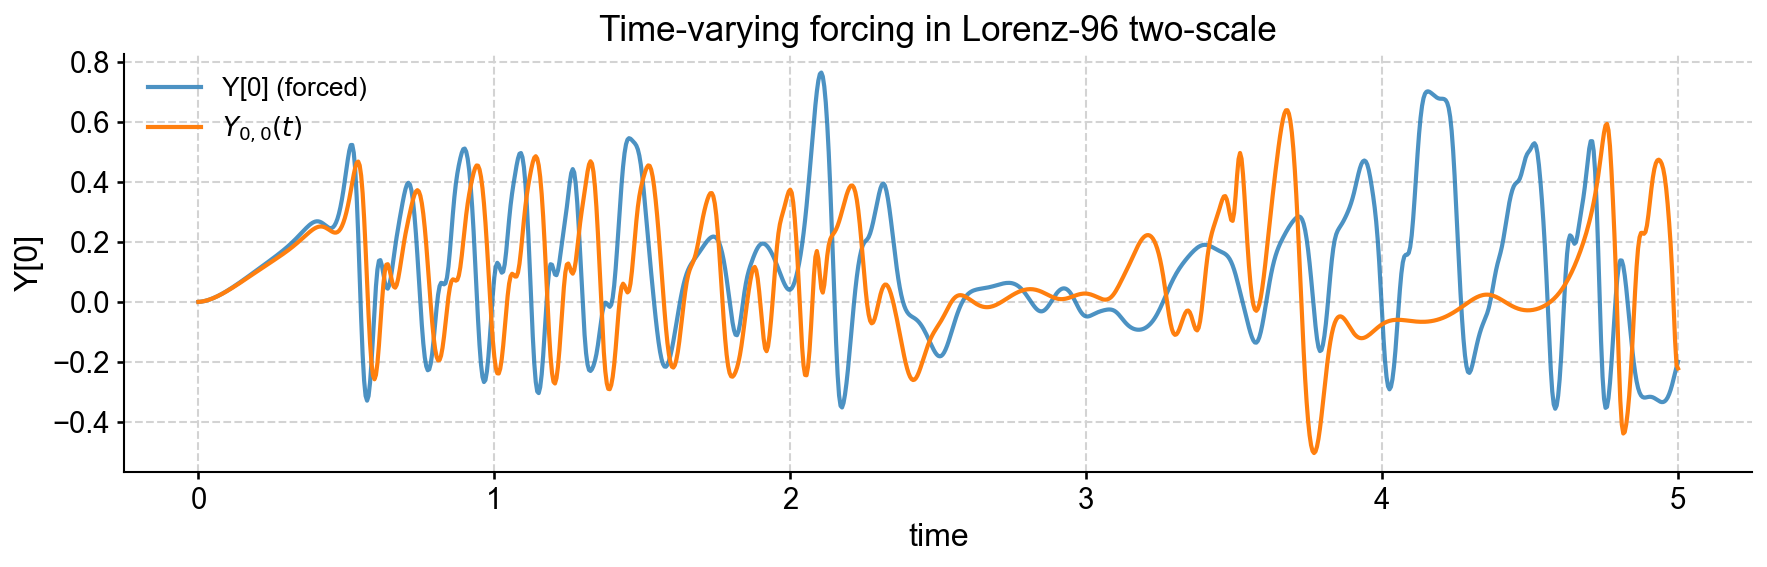

In [15]:
def forcing_func(t):
    return 10.0 + 2.0 * np.sin(2 * np.pi * t / 2.0)

forcing = pb.core.Forcing(forcing_func)
model_forced = Lorenz96TwoScale(forcing=forcing, K=K, J=J, F=F, h=h, b=b, c=c, exact_rhs=True)
model_forced.integrate(t_span=t_span, y0=y0, method='l96_rk4', kwargs={'dt': dt, 'si': si})

state_forced = model_forced.state_variables
X_forced = np.column_stack([state_forced[f'x{i}'] for i in range(K)])
Y_forced = np.column_stack([state_forced[f'y{i}'] for i in range(K * J)])
t_forced = model_forced.time

plt.figure(figsize=(12, 4), dpi=150)
plt.plot(t_forced, Y_forced[:, 0], label='Y[0] (forced)', alpha=0.8)
# plt.plot(t, X[:, 0], label="$X_0(t)$")
plt.plot(t, Y[:, 0], label="$Y_{0,0}(t)$")
plt.xlabel('time')
plt.ylabel('Y[0]')
plt.title('Time-varying forcing in Lorenz-96 two-scale')
plt.legend()
plt.tight_layout()
